<a href="https://colab.research.google.com/github/Saiful-2/notebooks/blob/main/SUB_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name: Customer Segmentation (K-Means)
### Objective: Group customers based on Income and Spending Score

In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Step 2: Load Dataset
# ============================================================

url = "http://raw.githubusercontent.com/Saiful-2/datasets/main/Mall_Customers.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# ============================================================
# Step 3: Explore Dataset
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
# ============================================================
# Step 4: Select Features
# Annual Income and Spending Score
# ============================================================

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("\nSelected Features Shape:")
print(X.shape)


Selected Features Shape:
(200, 2)


In [5]:
# ============================================================
# Step 5: Define Euclidean Distance Function
# ============================================================

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [6]:
# ============================================================
# Step 6: Implement K-Means Manually
# ============================================================

def manual_kmeans(X, K, max_iterations=100):

    # Randomly select initial centroids
    np.random.seed(42)
    random_indices = np.random.choice(len(X), K, replace=False)
    centroids = X[random_indices]

    for iteration in range(max_iterations):

        clusters = []

        # Assign each point to nearest centroid
        for point in X:
            distances = [euclidean_distance(point, centroid)
                         for centroid in centroids]

            cluster = np.argmin(distances)
            clusters.append(cluster)

        clusters = np.array(clusters)

        # Calculate new centroids
        new_centroids = []

        for k in range(K):

            cluster_points = X[clusters == k]

            if len(cluster_points) > 0:
                new_centroid = cluster_points.mean(axis=0)
            else:
                new_centroid = centroids[k]

            new_centroids.append(new_centroid)

        new_centroids = np.array(new_centroids)

        # Stop if centroids do not change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids

In [7]:
# ============================================================
# Step 7: Run K-Means for K = 2
# ============================================================

clusters2, centroids2 = manual_kmeans(X, K=2)

print("\nK = 2 Completed")
print("Centroids:")
print(centroids2)


K = 2 Completed
Centroids:
[[79.6        50.12727273]
 [37.28888889 50.28888889]]


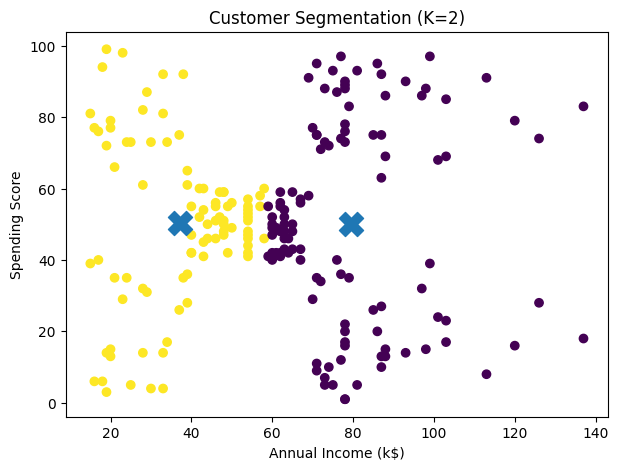

In [8]:
# ============================================================
# Step 8: Plot Clusters for K = 2
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1],
            c=clusters2,
            cmap='viridis')

plt.scatter(centroids2[:,0],
            centroids2[:,1],
            marker='X',
            s=300)

plt.title("Customer Segmentation (K=2)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [9]:
# ============================================================
# Step 9: Run K-Means for K = 3
# ============================================================

clusters3, centroids3 = manual_kmeans(X, K=3)

print("\nK = 3 Completed")
print("Centroids:")
print(centroids3)


K = 3 Completed
Centroids:
[[86.53846154 82.12820513]
 [44.15447154 49.82926829]
 [87.         18.63157895]]


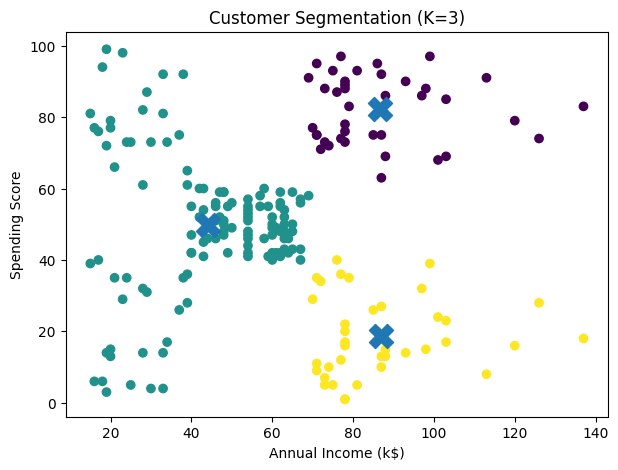

In [10]:
# ============================================================
# Step 10: Plot Clusters for K = 3
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1],
            c=clusters3,
            cmap='viridis')

plt.scatter(centroids3[:,0],
            centroids3[:,1],
            marker='X',
            s=300)

plt.title("Customer Segmentation (K=3)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [11]:
# ============================================================
# Step 11: Run K-Means for K = 4
# ============================================================

clusters4, centroids4 = manual_kmeans(X, K=4)

print("\nK = 4 Completed")
print("Centroids:")
print(centroids4)


K = 4 Completed
Centroids:
[[86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [48.16831683 43.3960396 ]
 [87.         18.63157895]]


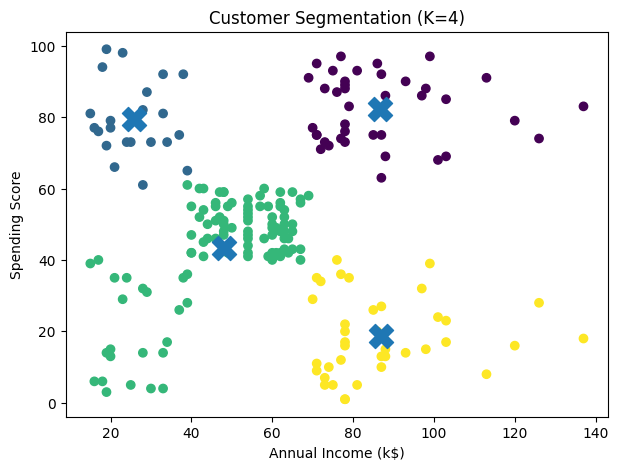

In [12]:
# ============================================================
# Step 12: Plot Clusters for K = 4
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1],
            c=clusters4,
            cmap='viridis')

plt.scatter(centroids4[:,0],
            centroids4[:,1],
            marker='X',
            s=300)

plt.title("Customer Segmentation (K=4)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [13]:
# ============================================================
# Step 13: Show Customer Groups for K = 4
# ============================================================

df['Cluster'] = clusters4

print("\nCustomer Groups:")
print(df[['CustomerID',
          'Annual Income (k$)',
          'Spending Score (1-100)',
          'Cluster']].head(20))


Customer Groups:
    CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0            1                  15                      39        2
1            2                  15                      81        1
2            3                  16                       6        2
3            4                  16                      77        1
4            5                  17                      40        2
5            6                  17                      76        1
6            7                  18                       6        2
7            8                  18                      94        1
8            9                  19                       3        2
9           10                  19                      72        1
10          11                  19                      14        2
11          12                  19                      99        1
12          13                  20                      15        2
13          14                

In [14]:
# ============================================================
# Step 14: Count Customers in Each Cluster
# ============================================================

print("\nNumber of Customers in Each Cluster:")
print(df['Cluster'].value_counts())


Number of Customers in Each Cluster:
Cluster
2    101
0     39
3     38
1     22
Name: count, dtype: int64
